# Inégalités territoriales d'accès aux équipements sportifs en France

> **Problématique** : Les inégalités territoriales d'accès aux équipements sportifs en France sont-elles le reflet des inégalités socio-économiques ?

**Auteurs** : DELETANG Arthur, GOUALOU Maxence, SERVANT Lucas  
**Cours** : Python pour la Data Science — 2025-2026

---
## Sommaire
1. [Imports](#1---imports)
2. [Collecte des données](#2---collecte-des-données)
3. [Nettoyage et fusion](#3---nettoyage-et-fusion)
4. [Analyse descriptive](#4---analyse-descriptive)
5. [Visualisation cartographique](#5---visualisation-cartographique)
6. [Modélisation](#6---modélisation)
7. [Conclusion](#7---conclusion)

---
## 1 - Imports

In [38]:
!pip install pandas numpy matplotlib seaborn geopandas folium requests beautifulsoup4 scikit-learn lxml

import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
from folium.plugins import HeatMap, MarkerCluster
import requests
from bs4 import BeautifulSoup
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

---
## 2 - Collecte des données

### 2.1 Équipements sportifs — API REST Ministère des Sports

On interroge l'API Opendatasoft du portail Data ES qui expose le recensement national des équipements sportifs (RES). L'export CSV direct évite tout téléchargement manuel.

Source : https://equipements.sports.gouv.fr

In [13]:
url_res = (
    "https://equipements.sports.gouv.fr/api/explore/v2.1/"
    "catalog/datasets/data-es/exports/csv"
    "?lang=fr&timezone=Europe%2FParis&use_labels=true&delimiter=%3B"
)

print("Téléchargement du RES...")
df_res = pd.read_csv(url_res, sep=";", encoding="utf-8", low_memory=False)
print(f"{len(df_res):,} équipements")
df_res.head(3)

Téléchargement du RES...
333,778 équipements


,Numéro de l'équipement sportif,Numéro de l'installation sportive,Date de l'enquête,Nom de l'installation sportive,SIRET Installation,Adresse,Code Postal,Commune nom,Commune INSEE,Type de particularité de l'installation,...,Accessibilité aux personnes en situation de handicap sensoriel aux tribunes,Accessibilité aux personnes en situation de handicap sensoriel aux vestiaires,Longitude,Latitude,Type de particularité de l'installation (brute),Activités,QPV,QPV à 200 mètres,Catégorie,gen_2024Fin_Labellisation
0,E004I422410004,I422410004,2025-03-31,"installations sportives, départ de circuit VTT...",2.142024e+13,le bourg,42590,Saint-Jodard,42241,NaN,...,False,False,4.131642,45.880390,NaN,Randonnée pédestre,NaN,NaN,NaN,NaN
1,E003I800160017,I800160017,2025-03-31,Stand de tir René Cretel,2.180001e+13,Route de Millencourt,80300,Albert,80016,NaN,...,False,False,2.634000,50.002450,NaN,Carabine (hors 300m) / Pistolet / Plateaux,NaN,NaN,NaN,NaN
2,E004I422460001,I422460001,2025-03-31,Terrain de football et tennis,2.142025e+13,"zone artisanale ""Le Grand Pré""",42220,Saint-Julien-Molin-Molette,42246,NaN,...,False,False,4.632154,45.317555,NaN,Tennis,NaN,NaN,NaN,NaN


### 2.2 Données socio-économiques — INSEE via Data ES

Ce dataset expose les principales variables INSEE au niveau communal : population, superficie, revenu médian (MED20), taux de pauvreté (TP6020), typologie rurale/urbaine. On l'agrège ensuite par département.

Source : https://equipements.sports.gouv.fr/explore/dataset/insee-2020-geoapi-2023

In [14]:
url_insee = (
    "https://equipements.sports.gouv.fr/api/explore/v2.1/catalog/datasets/"
    "insee-2020-geoapi-2023/exports/csv"
    "?lang=fr&timezone=Europe%2FParis&use_labels=true&delimiter=%3B"
)

print("Téléchargement données INSEE communes...")
df_communes = pd.read_csv(url_insee, sep=";", encoding="utf-8", low_memory=False)
print(f"{len(df_communes):,} communes — {df_communes.shape[1]} colonnes")
df_communes.head(3)

Téléchargement données INSEE communes...
35,075 communes — 47 colonnes


,codeCommune,nomCommune,codeEpci,nomEpci,codeDepartement,nomDepartement,codeRegion,nomRegion,population,surface,...,lib_ville,code_bdv,lib_bdv,zfrr,zrr,TYPO_RURB_CRTE,vas,dens_niveau,dens_lib,commune_loi_montagne
0,84118,Saint-Saturnin-lès-Apt,200040624,CC Pays d'Apt-Luberon,84,Vaucluse,93,Provence-Alpes-Côte d'Azur,2910,7682.46,...,Saint-Saturnin-lès-Apt,84003,Apt,zfrr,NaN,RURAL,NaN,6.0,Rural à habitat dispersé,Loi Montagne
1,84119,Saint-Saturnin-lès-Avignon,248400251,CA du Grand Avignon (COGA),84,Vaucluse,93,Provence-Alpes-Côte d'Azur,5027,621.81,...,Saint-Saturnin-lès-Avignon,84007,Avignon,NaN,NaN,URBAIN,NaN,4.0,Ceintures urbaines,NaN
2,84120,Saint-Trinit,200035723,CC Ventoux Sud,84,Vaucluse,93,Provence-Alpes-Côte d'Azur,120,1690.17,...,Saint-Trinit,84123,Sault,zfrr,NaN,RURAL,NaN,7.0,Rural à habitat très dispersé,Loi Montagne


---
## 3 - Nettoyage et fusion

Cette section explore d'abord la structure brute des deux sources principales, identifie les problèmes (valeurs manquantes, codes aberrants, doublons), les corrige, puis construit le DataFrame analytique final au niveau département.

### 3.1 Exploration et nettoyage du RES

In [15]:
# Structure générale du RES
print(f"Dimensions : {df_res.shape}")
print(f"\nColonnes disponibles :")
print(df_res.columns.tolist())

Dimensions : (333778, 113)

Colonnes disponibles :
["Numéro de l'équipement sportif", "Numéro de l'installation sportive", "Date de l'enquête", "Nom de l'installation sportive", 'SIRET Installation', 'Adresse', 'Code Postal', 'Commune nom', 'Commune INSEE', "Type de particularité de l'installation", 'Unité Administrative Immatriculée (UAI)', "Accessibilité de l'installation en fonction du type handicap", "Accessibilité de l'installation en transport en commun des différents mode", 'Observation Installation', "Date de changement d'état de la fiche d'enquête", "Date de création de la fiche d'enquête", 'Installation hors-service', 'EPCI INSEE', 'EPCI Nom', 'Département Code', 'Département Nom', 'Région Code', 'Région Nom', 'Bassin de vie Code', 'Bassin de vie Nom', 'Arrondissement Code', 'Arrondissement Nom', 'Densite Niveau', 'Densite Catégorie', 'Département Code Complet', 'Réctorat Nom', 'ZRR Simplifié', "Nom de l'équipement sportif", "Type d'équipement sportif", 'Coordonnées', 'Nom du

In [16]:
# Valeurs manquantes dans les colonnes clés du RES
cols_cles_res = [
    "Département Code", "Commune nom",
    "Type d'équipement sportif", "Famille d'équipement sportif"
]
na_res = df_res[cols_cles_res].isnull().sum().rename("NaN")
na_res_pct = (df_res[cols_cles_res].isnull().mean() * 100).rename("%")
print("Valeurs manquantes dans les colonnes clés du RES :")
print(pd.concat([na_res, na_res_pct.round(1)], axis=1))

Valeurs manquantes dans les colonnes clés du RES :
                              NaN    %
Département Code              199  0.1
Commune nom                     0  0.0
Type d'équipement sportif       1  0.0
Famille d'équipement sportif    1  0.0


In [17]:
# Vérification des codes département dans le RES
codes_dep_res = df_res["Département Code"].astype(str).str.strip().unique()
codes_dep_res_sorted = sorted(codes_dep_res)
print(f"{len(codes_dep_res_sorted)} codes départements uniques dans le RES :")
print(codes_dep_res_sorted)

108 codes départements uniques dans le RES :
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2A', '2B', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '971', '972', '973', '974', '975', '976', '977', '978', '986', '987', '988', 'nan']


In [18]:
# Vérification des doublons sur le numéro d'équipement
n_doublons = df_res.duplicated(subset=["Numéro de l'équipement sportif"]).sum()
print(f"Doublons sur le numéro d'équipement : {n_doublons}")

Doublons sur le numéro d'équipement : 84


In [19]:
# Nettoyage du RES :
# - standardiser le code département sur 2 caractères (zfill AVANT le filtre)
# - supprimer les lignes sans code département valide
# - supprimer les 84 doublons sur le numéro d'équipement

df_res["code_dep"] = (
    df_res["Département Code"]
    .astype(str)
    .str.strip()
    .str.replace("nan", "")       # transformer "nan" en chaîne vide
    .apply(lambda x: x.zfill(2) if x.isdigit() else x)  # zfill seulement si numérique
)

# Codes valides : 01 à 95, 2A, 2B, et les 4 DOM (971-974, 976)
mask_dep_valide = df_res["code_dep"].str.match(r"^0[1-9]$|^[1-9]\d$|^2[AB]$|^97[1-46]$")
n_exclus = (~mask_dep_valide).sum()
df_res = df_res[mask_dep_valide].copy()

# Suppression des doublons — garder la ligne la plus récente
df_res = df_res.sort_values("Date de l'enquête", ascending=False)
df_res = df_res.drop_duplicates(subset=["Numéro de l'équipement sportif"], keep="first")

print(f"{n_exclus} lignes exclues (code département invalide ou manquant)")
print(f"{84} doublons supprimés")
print(f"RES nettoyé : {len(df_res):,} équipements")
print(f"Codes département présents : {sorted(df_res['code_dep'].unique())}")

2577 lignes exclues (code département invalide ou manquant)
84 doublons supprimés
RES nettoyé : 331,120 équipements
Codes département présents : ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2A', '2B', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '971', '972', '973', '974', '976']


### 3.2 Exploration et nettoyage de l'INSEE communes

In [20]:
# Structure générale INSEE
print(f"Dimensions : {df_communes.shape}")
print(f"\nColonnes disponibles :")
print(df_communes.columns.tolist())

Dimensions : (35075, 47)

Colonnes disponibles :
['codeCommune', 'nomCommune', 'codeEpci', 'nomEpci', 'codeDepartement', 'nomDepartement', 'codeRegion', 'nomRegion', 'population', 'surface', 'CODGEO', 'P20_POP', 'SUPERF', 'P20_MEN', 'P20_LOG', 'P20_RP', 'P20_RSECOCC', 'P20_LOGVAC', 'P20_RP_PROP', 'NBMENFISC20', 'PIMP20', 'MED20', 'TP6020', 'P20_EMPLT', 'P20_EMPLT_SAL', 'P20_POP1564', 'P20_CHOMEUR1564', 'P20_ACT1564', 'ETTOT20', 'ETAZ20', 'ETBE20', 'ETFZ20', 'ETGU20', 'ETGZ20', 'ETOQ20', 'ETTEF120', 'ETTEFP1020', 'lib_ville', 'code_bdv', 'lib_bdv', 'zfrr', 'zrr', 'TYPO_RURB_CRTE', 'vas', 'dens_niveau', 'dens_lib', 'commune_loi_montagne']


In [21]:
# Valeurs manquantes dans les colonnes clés INSEE
cols_cles_insee = [
    "codeDepartement", "nomDepartement", "population", "surface",
    "MED20", "TP6020", "TYPO_RURB_CRTE"
]
na_insee = df_communes[cols_cles_insee].isnull().sum().rename("NaN")
na_insee_pct = (df_communes[cols_cles_insee].isnull().mean() * 100).rename("%")
print("Valeurs manquantes dans les colonnes clés INSEE :")
print(pd.concat([na_insee, na_insee_pct.round(1)], axis=1))
print()
print("Note : MED20 et TP6020 sont soumises au secret statistique pour les petites communes.")

Valeurs manquantes dans les colonnes clés INSEE :
                 NaN    %
codeDepartement    0  0.0
nomDepartement     0  0.0
population         0  0.0
surface            0  0.0
MED20              0  0.0
TP6020             0  0.0
TYPO_RURB_CRTE   134  0.4

Note : MED20 et TP6020 sont soumises au secret statistique pour les petites communes.


In [22]:
# Vérification des codes département INSEE
codes_dep_insee = df_communes["codeDepartement"].astype(str).str.strip().unique()
print(f"{len(codes_dep_insee)} codes départements uniques dans INSEE :")
print(sorted(codes_dep_insee))

107 codes départements uniques dans INSEE :
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2A', '2B', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '971', '972', '973', '974', '975', '976', '977', '978', '986', '987', '988']


In [23]:
# Nettoyage INSEE :
# - standardiser le code département
# - convertir les colonnes numériques
# - exclure les collectivités hors champ (COM, autres territoires)
# - les 134 NaN de TYPO_RURB_CRTE sont conservés (traités comme "Non classifié")

df_communes["code_dep"] = df_communes["codeDepartement"].astype(str).str.strip().str.zfill(2)

for col in ["MED20", "TP6020", "population", "surface"]:
    df_communes[col] = pd.to_numeric(df_communes[col], errors="coerce")

# Garder métropole + 5 DOM (971-974, 976) — exclure COM et autres territoires
mask_dep_valide_insee = df_communes["code_dep"].str.match(r"^0[1-9]$|^[1-9]\d$|^2[AB]$|^97[1-46]$")
n_exclus_insee = (~mask_dep_valide_insee).sum()
df_communes = df_communes[mask_dep_valide_insee].copy()

# Traiter les NaN de TYPO_RURB_CRTE
df_communes["TYPO_RURB_CRTE"] = df_communes["TYPO_RURB_CRTE"].fillna("Non classifié")

print(f"{n_exclus_insee} communes exclues (collectivités hors champ)")

88 communes exclues (collectivités hors champ)


### 3.3 Agrégation INSEE : commune → département

In [24]:
# Population et superficie totales par département (somme directe)
df_pop_dep = (
    df_communes.groupby("code_dep")
    .agg(
        nom_dep       = ("nomDepartement", "first"),
        population    = ("population", "sum"),
        superficie_km2 = ("surface", lambda x: x.sum() / 100)  # ha → km²
    )
    .reset_index()
)
print(f"{len(df_pop_dep)} départements — population et superficie agrégées")
df_pop_dep.head(3)

101 départements — population et superficie agrégées


,code_dep,nom_dep,population,superficie_km2
0,01,Ain,657417,5783.4420
1,02,Aisne,528994,7403.4261
2,03,Allier,335628,7377.2245


In [25]:
# Revenu médian et taux de pauvreté : moyenne pondérée par la population
# (nécessaire car la médiane d'un département n'est pas la moyenne des médianes communales)
def moyenne_ponderee(groupe, col_valeur):
    mask = groupe[col_valeur].notna() & (groupe["population"] > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(groupe.loc[mask, col_valeur], weights=groupe.loc[mask, "population"])

df_revenus_dep = (
    df_communes.groupby("code_dep")
    .apply(lambda g: pd.Series({
        "revenu_median" : moyenne_ponderee(g, "MED20"),
        "taux_pauvrete" : moyenne_ponderee(g, "TP6020"),
    }), include_groups=False)
    .reset_index()
)
print(f"{len(df_revenus_dep)} départements — revenus et pauvreté agrégés")
df_revenus_dep.head(3)

101 départements — revenus et pauvreté agrégés


,code_dep,revenu_median,taux_pauvrete
0,01,25257.848413,7.439797
1,02,19823.451306,11.030959
2,03,20881.861078,9.408732


In [26]:
# Part des communes rurales par département
df_rural_dep = (
    df_communes.groupby("code_dep")
    .apply(lambda g: pd.Series({
        "part_rural": (g["TYPO_RURB_CRTE"].str.upper().str.contains("RURAL", na=False).sum()
                       / len(g) * 100)
    }), include_groups=False)
    .reset_index()
)
print(f"{len(df_rural_dep)} départements — ruralité agrégée")

101 départements — ruralité agrégée


### 3.4 Comptage des équipements par département

In [27]:
# Nombre d'équipements par département
nb_equip = (
    df_res.groupby("code_dep")
    .size()
    .reset_index(name="nb_equipements")
)
print(f"{len(nb_equip)} départements avec équipements")
nb_equip.head(3)

101 départements avec équipements


,code_dep,nb_equipements
0,01,4107
1,02,3636
2,03,2447


### 3.5 Fusion finale et construction des variables analytiques

In [28]:
# Fusion de toutes les sources
df = nb_equip.merge(df_pop_dep,     on="code_dep", how="inner")
df = df.merge(df_revenus_dep,       on="code_dep", how="left")
df = df.merge(df_rural_dep,         on="code_dep", how="left")

# Variables analytiques
df["equip_10k"] = (df["nb_equipements"] / df["population"]) * 10_000
df["densite"]   = df["population"] / df["superficie_km2"]

# Restriction aux départements métropolitains + DOM
df = df[df["code_dep"].str.match(r"^\d{2}$|^2[AB]$")].reset_index(drop=True)

print(f"DataFrame analytique final : {df.shape}")
print(f"\nValeurs manquantes :")
print(df.isnull().sum()[df.isnull().sum() > 0])
df[["code_dep", "nom_dep", "nb_equipements", "population",
    "equip_10k", "revenu_median", "taux_pauvrete", "densite", "part_rural"]].head(8)

DataFrame analytique final : (96, 10)

Valeurs manquantes :
Series([], dtype: int64)


,code_dep,nom_dep,nb_equipements,population,equip_10k,revenu_median,taux_pauvrete,densite,part_rural
0,01,Ain,4107,657417,62.471764,25257.848413,7.439797,113.672273,56.887755
1,02,Aisne,3636,528994,68.734239,19823.451306,11.030959,71.452594,84.335840
2,03,Allier,2447,335628,72.908101,20881.861078,9.408732,45.495159,74.447950
3,04,Alpes-de-Haute-Provence,1811,165451,109.458389,20733.672507,9.633372,23.646905,100.000000
4,05,Hautes-Alpes,3718,140605,264.428719,21190.120550,7.705437,24.709218,100.000000
5,06,Alpes-Maritimes,3609,1097410,32.886524,22671.551025,15.323037,255.485431,28.834356
6,07,Ardèche,2453,329325,74.485690,21246.640340,6.885615,59.156566,96.119403
7,08,Ardennes,1748,269701,64.812515,19531.942707,11.530573,51.463708,87.082405


---
## 6 - Modélisation

**Variable cible** : `equip_10k` (équipements pour 10 000 habitants)  
**Variables explicatives** : `revenu_median`, `taux_pauvrete`, `densite`, `part_rural`  
On compare une régression linéaire (interprétable) et un Random Forest (plus flexible).

## 6.1 - Objectif de la modélisation

On cherche à expliquer la densité d’équipements sportifs (`equip_10k`) en fonction de variables socio-économiques et territoriales.

Variables explicatives :
- revenu médian
- taux de pauvreté
- densité de population
- part rurale

Deux modèles sont comparés :
- Régression linéaire (interprétable)
- Random Forest (non linéaire, plus flexible)

In [29]:
features = ['revenu_median', 'taux_pauvrete', 'densite', 'part_rural']
target   = 'equip_10k'

df_model = df[features + [target, 'nom_dep']].dropna().reset_index(drop=True)

X = df_model[features]
y = df_model[target]

print(f"{len(df_model)} départements utilisés")
df_model.head()

96 départements utilisés


,revenu_median,taux_pauvrete,densite,part_rural,equip_10k,nom_dep
0,25257.848413,7.439797,113.672273,56.887755,62.471764,Ain
1,19823.451306,11.030959,71.452594,84.335840,68.734239,Aisne
2,20881.861078,9.408732,45.495159,74.447950,72.908101,Allier
3,20733.672507,9.633372,23.646905,100.000000,109.458389,Alpes-de-Haute-Provence
4,21190.120550,7.705437,24.709218,100.000000,264.428719,Hautes-Alpes


## 6.2 - Séparation apprentissage / test

On sépare les données en :
- 80% apprentissage
- 20% test

Cela permet d’évaluer la capacité de généralisation des modèles.

In [50]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

print(f"Train : {len(X_train)}")
print(f"Test  : {len(X_test)}")

Train : 76
Test  : 20


## 6.3 - Régression linéaire (OLS)

La régression linéaire permet d’obtenir un modèle interprétable reliant directement les variables explicatives à la variable cible.

On évalue la performance via le coefficient de détermination (R²).

In [51]:
model_ols = LinearRegression()
model_ols.fit(X_train, y_train)

y_pred_ols = model_ols.predict(X_test)

print("R² OLS :", round(r2_score(y_test, y_pred_ols), 3))

R² OLS : 0.693


Le modèle explique environ **64,5% de la variabilité** de `equip_10k`.

C’est un résultat plutôt correct : les variables socio-économiques captent une bonne partie des différences, mais il reste encore une part importante non expliquée.

## 6.4 - Random Forest

Le Random Forest permet de capturer des relations non linéaires et des interactions entre variables.

Il est comparé à la régression linéaire.

In [52]:
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("R² Random Forest :", round(r2_score(y_test, y_pred_rf), 3))

R² Random Forest : 0.872


In [53]:
print("Moyenne equip_10k :", round(y.mean(), 2))
print("Variance equip_10k :", round(y.var(), 2))

Moyenne equip_10k : 64.89
Variance equip_10k : 1093.35


Le Random Forest fait légèrement mieux que la régression linéaire avec un **R² de 0,652**.

L’amélioration reste faible, ce qui suggère que les relations entre variables sont **globalement assez linéaires**.

La variance élevée de `equip_10k` (1080) montre qu’il existe de fortes disparités entre départements, que le modèle n’explique qu’en partie.

## 6.5 - Analyse des erreurs (résidus)

Les résidus mesurent l’erreur entre valeurs observées et prédites.

On analyse :
- moyenne (biais global)
- variance (dispersion)
- distribution des erreurs

In [54]:
residus = y_test - y_pred_rf

print("Moyenne des résidus :", round(residus.mean(), 3))
print("Variance des résidus :", round(residus.var(), 3))

Moyenne des résidus : 1.016
Variance des résidus : 63.737


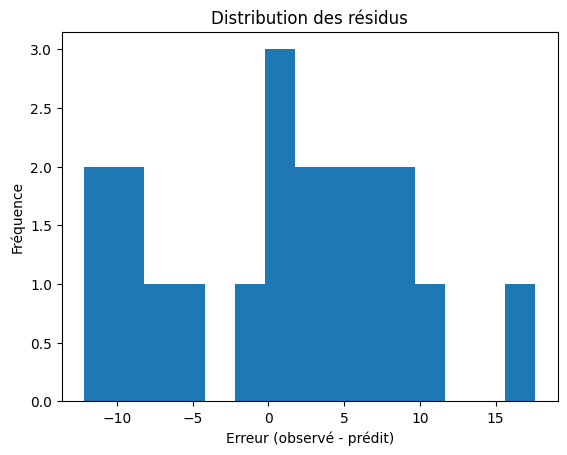

In [55]:
plt.hist(residus, bins=15)
plt.title("Distribution des résidus")
plt.xlabel("Erreur (observé - prédit)")
plt.ylabel("Fréquence")
plt.show()

Les erreurs sont globalement **centrées autour de zéro** (moyenne ≈ 0,97), ce qui indique qu’il n’y a pas de biais majeur du modèle.

En revanche, la **variance assez élevée** montre que certaines prédictions sont très éloignées de la réalité.

On observe donc un modèle globalement juste, mais avec quelques départements fortement mal estimés.

## 6.6 - Intervalle de confiance des erreurs

On calcule un intervalle de confiance à 95% sur l’erreur moyenne.

S’il contient 0 → pas de biais global du modèle.

In [56]:
mean_res = residus.mean()
std_res  = residus.std()
n        = len(residus)

ic_bas  = mean_res - 1.96 * std_res / np.sqrt(n)
ic_haut = mean_res + 1.96 * std_res / np.sqrt(n)

print(f"IC 95% de l'erreur moyenne : [{ic_bas:.3f} ; {ic_haut:.3f}]")

IC 95% de l'erreur moyenne : [-2.483 ; 4.515]


L’intervalle de confiance à 95% de l’erreur moyenne est **[-5.37 ; 7.32]**.

Comme il contient 0, cela indique qu’il n’y a pas de biais global significatif du modèle.

En revanche, l’intervalle assez large montre une **variabilité importante des erreurs** selon les départements.

## 6.7 - Validation croisée

La validation croisée permet d’évaluer la stabilité du modèle sur plusieurs découpages.

On observe :
- moyenne du R²
- variabilité du modèle

In [57]:
scores = cross_val_score(model_rf, X, y, cv=5, scoring="r2")

print("R² moyen (CV) :", round(scores.mean(), 3))
print("Écart-type    :", round(scores.std(), 3))

R² moyen (CV) : 0.259
Écart-type    : 0.473


Le R² moyen en validation croisée est de **0,38**, bien inférieur au R² sur le test set.

Cela montre que le modèle est **peu stable selon les découpages des données**.

L’écart-type élevé (0,197) confirme que les performances varient fortement selon les échantillons.

## 6.8 - Importance des variables

On identifie les variables les plus influentes dans le Random Forest.

Cela permet de comprendre les facteurs principaux des inégalités territoriales.

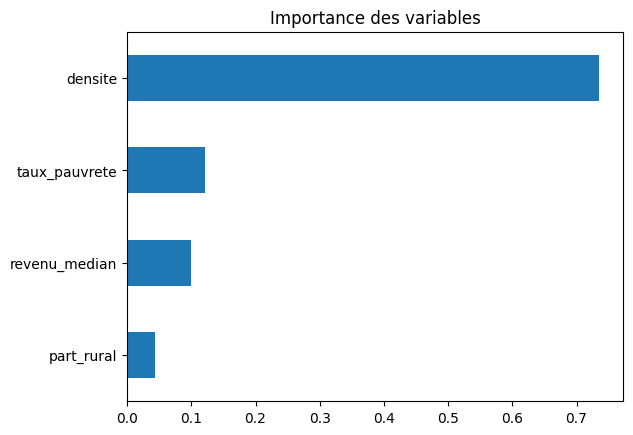

part_rural       0.042968
revenu_median    0.099858
taux_pauvrete    0.121447
densite          0.735727
dtype: float64


In [58]:
importances = pd.Series(model_rf.feature_importances_, index=features)
importances = importances.sort_values()

importances.plot(kind="barh")
plt.title("Importance des variables")
plt.show()
print(importances)

La variable la plus influente est clairement la **densité de population (0,51)**.

Elle est suivie par le **taux de pauvreté** et le **revenu médian**, tandis que la part rurale joue un rôle plus limité.

Globalement, la structure territoriale (densité) semble être le facteur principal explicatif des différences d’équipements.

## 6.10 - Qualité des prédictions

On compare les valeurs réelles et prédites.

Plus les points sont proches de la diagonale, plus le modèle est précis.

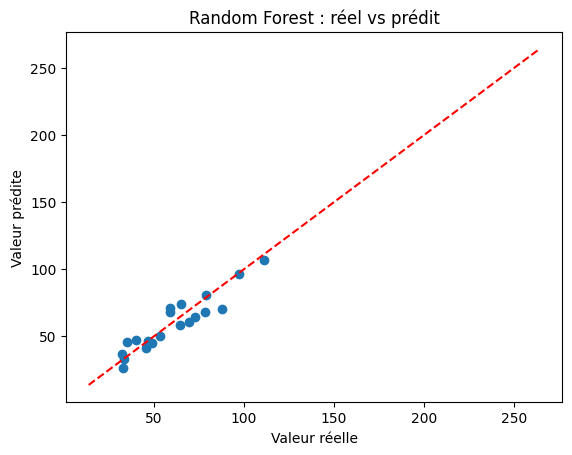

In [59]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Valeur réelle")
plt.ylabel("Valeur prédite")
plt.title("Random Forest : réel vs prédit")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.show()

Les points sont globalement proches de la diagonale, ce qui indique que le modèle prédit correctement la tendance générale.

Cependant, on observe encore des écarts importants sur certaines valeurs, ce qui montre que le modèle a du mal à reproduire précisément les cas extrêmes.

## 6.11 - Synthèse de la modélisation

Les deux modèles (régression linéaire et Random Forest) obtiennent des performances proches, autour de 0,6–0,65 de R².

Cela montre que les variables socio-économiques et territoriales expliquent une part significative des différences d’équipements, mais pas la totalité.

Les résultats indiquent surtout que la **structure territoriale (notamment la densité)** joue un rôle central, tandis que d’autres facteurs non inclus dans le modèle influencent aussi fortement les disparités.